### imports & directories

In [1]:
from pathlib import Path
import analysis.plot as plot
from models.qmlif import QMLIFNeuron
from models.synapse import Synapse
from models.current import *
from models.A_exc_B_inh_A import A_exc_B_inh_A
from analysis.metrics import calculate_metrics_firing_patterns

ROOT = Path.cwd().parent
FIG_DIR = ROOT / "fig/firing_patterns"
FIG_DIR.mkdir(parents=True, exist_ok=True)

patterns_data = {}

# Tonic spiking

{'n_spikes': 21,
 't_first': 0.28500000000000003,
 't_last': 9.950000000000001,
 'mean_isi': 0.48325000000000007,
 'cv_isi': 0.002109768903293039,
 'a': -6.463274740079489e-05}

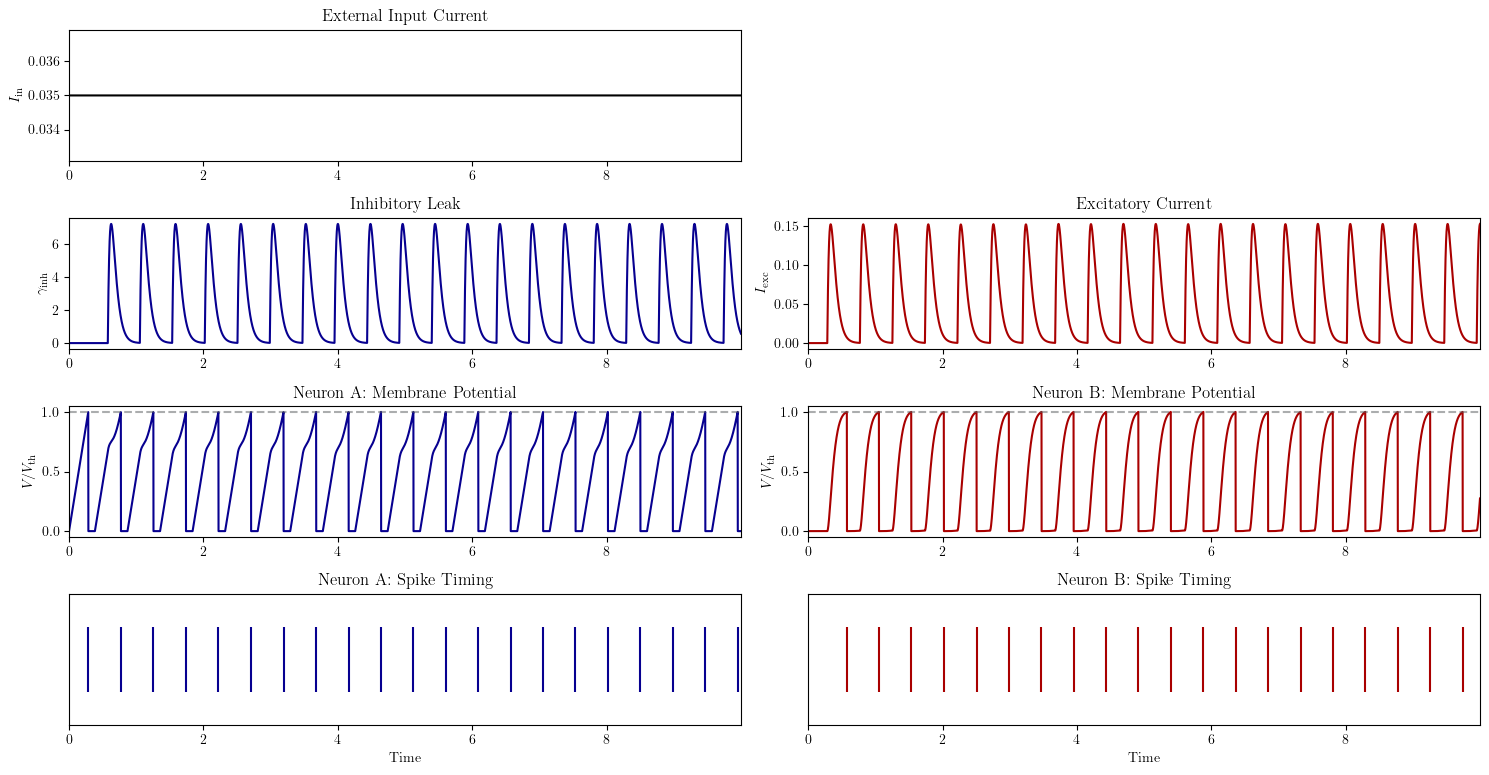

In [2]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.06, tau_syn=0.05)
syn_inh = Synapse(w=0.7, tau_syn=0.05)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = constant_current(T=T, T_in=T, I0=0.035)

simulation_data = network.simulate(T, current)
patterns_data["Tonic Spiking"] = simulation_data

metrics = calculate_metrics_firing_patterns(simulation_data["spkA"])

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "tonic.pdf", bbox_inches="tight")

metrics

# Initial bursting

{'n_spikes': 16,
 't_first': 0.01,
 't_last': 9.802,
 'mean_isi': 0.6527999999999999,
 'cv_isi': 0.9746063559720589,
 'a': 0.0702641273613758}

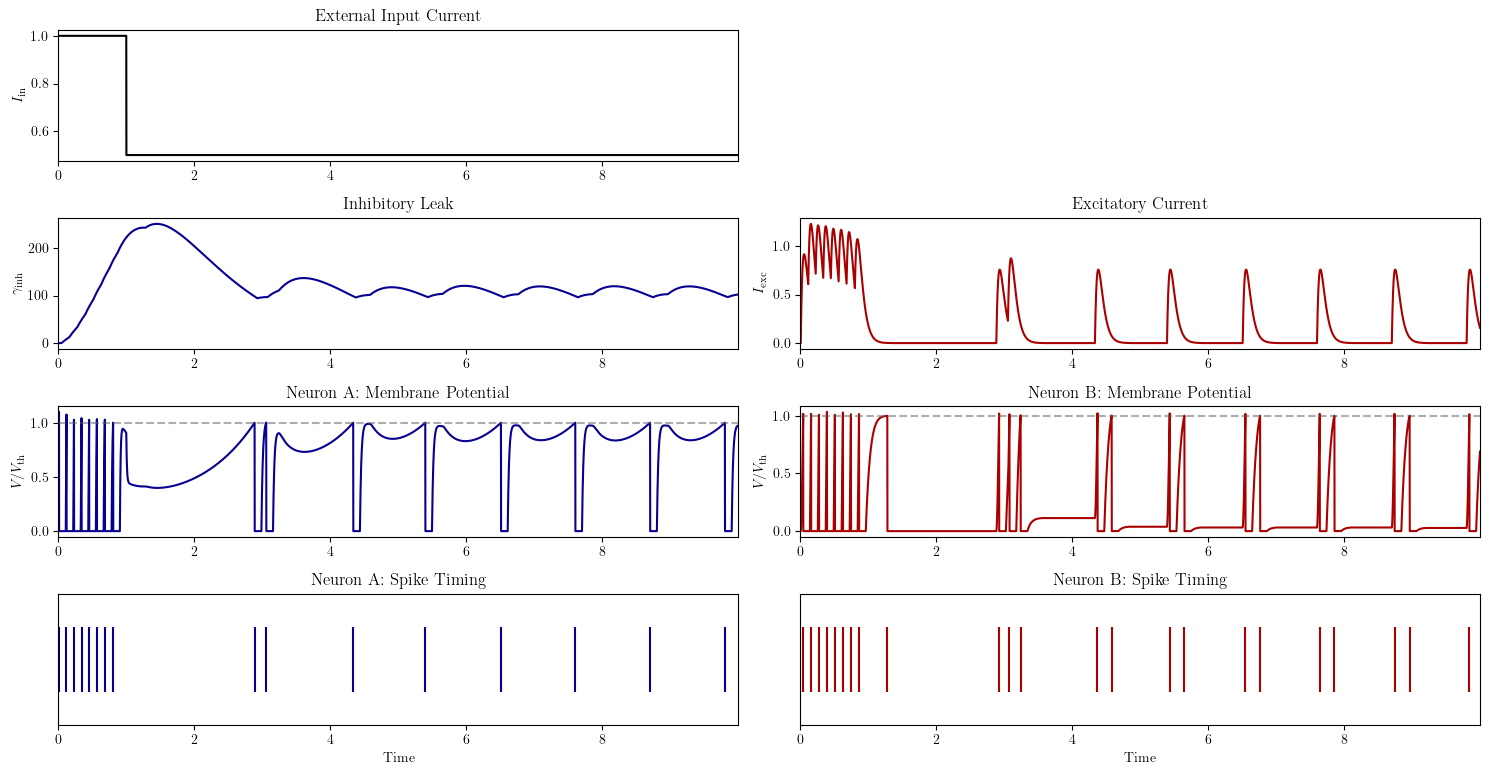

In [3]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.3, tau_syn=0.05)
syn_inh = Synapse(w=3, tau_syn=0.7)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = pulse_current_2(T=T, T_in=T, I1=1, I2=0.5, pulse1_duration=1, pulse2_duration=9, pulse1_times=[0], pulse2_times=[1])

simulation_data = network.simulate(T, current)
patterns_data["Initial Bursting"] = simulation_data

metrics = calculate_metrics_firing_patterns(simulation_data["spkA"])

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "initial_bursting.pdf", bbox_inches="tight")

metrics

# Regular bursting

{'n_spikes': 25,
 't_first': 0.033,
 't_last': 8.65,
 'mean_isi': 0.3590416666666667,
 'cv_isi': 1.3354055438246628,
 'a': 0.010019258321766025}

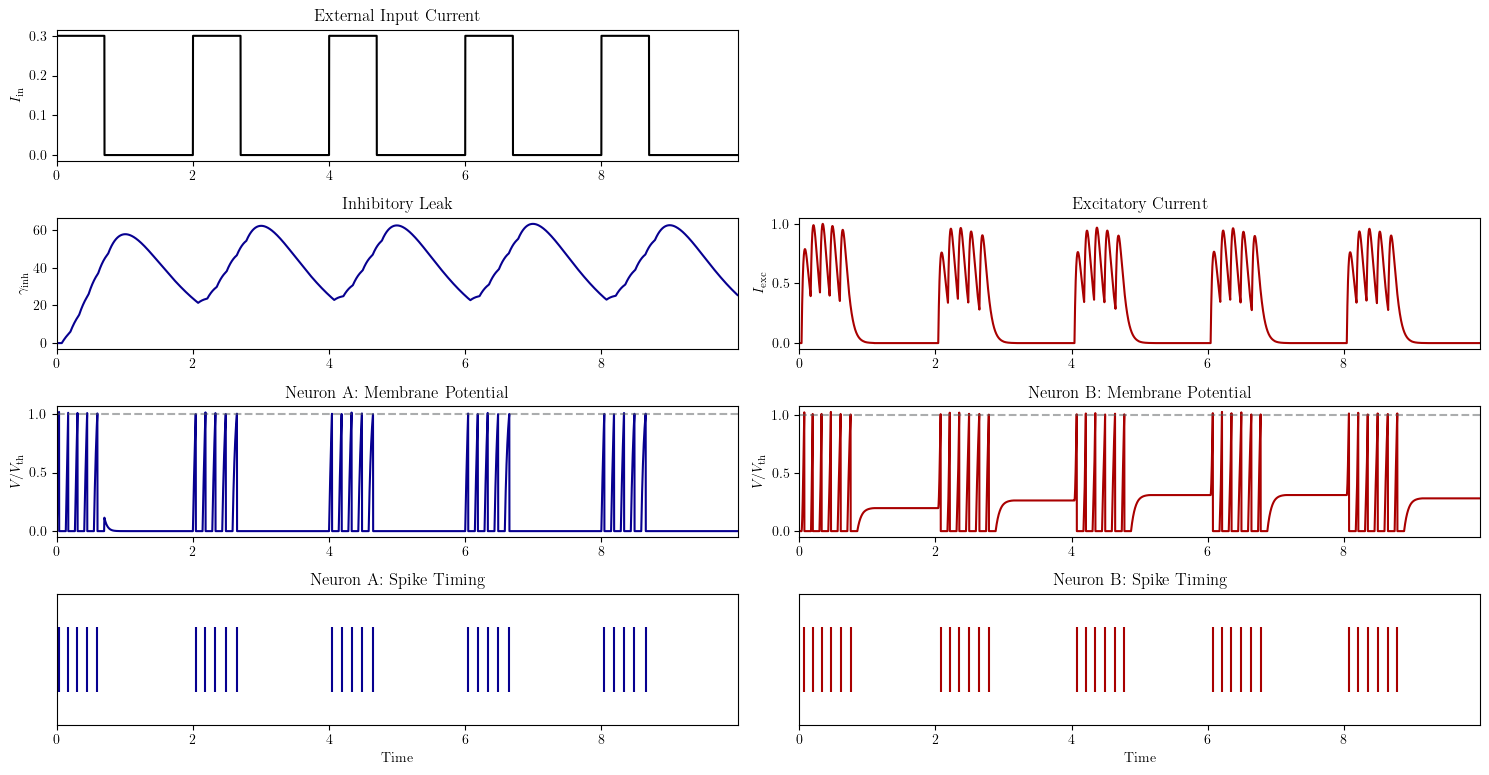

In [4]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.3, tau_syn=0.05)
syn_inh = Synapse(w=1, tau_syn=0.5)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = pulse_current(T=T, T_in=T, I0=0.3, pulse_duration=0.7, pulse_times=[0,2,4,6,8,10])

simulation_data = network.simulate(T, current)
patterns_data["Regular Bursting"] = simulation_data

metrics = calculate_metrics_firing_patterns(simulation_data["spkA"])

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "regular_bursting.pdf", bbox_inches="tight")

metrics

# Delayed regular bursting

{'n_spikes': 40,
 't_first': 1.0,
 't_last': 9.958,
 'mean_isi': 0.2296923076923077,
 'cv_isi': 1.357369188967005,
 'a': 0.0005406637675566912}

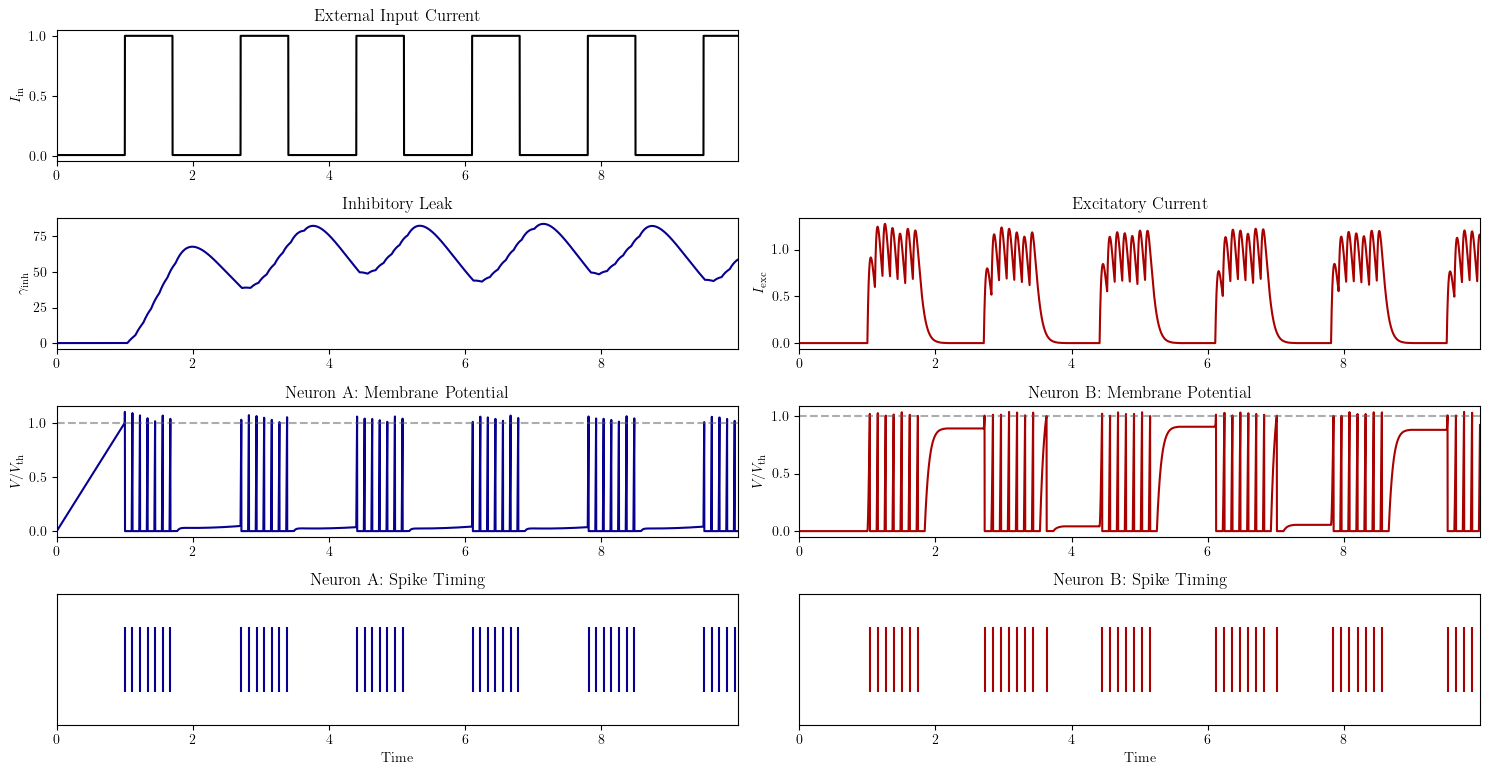

In [5]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.3, tau_syn=0.05)
syn_inh = Synapse(w=1, tau_syn=0.5)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = pulse_current_2(T=T, T_in=T, I1=0.01, I2=1, pulse1_duration=1, pulse2_duration=0.7, pulse1_times=[0, 1.7, 3.4, 5.1, 6.8, 8.5], pulse2_times=[1, 2.7, 4.4, 6.1, 7.8, 9.5])

simulation_data = network.simulate(T, current)
patterns_data["Delayed Bursting"] = simulation_data

metrics = calculate_metrics_firing_patterns(simulation_data["spkA"])

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "delayed_bursting.pdf", bbox_inches="tight")

metrics

# Transient spiking

{'n_spikes': 3,
 't_first': 0.105,
 't_last': 0.387,
 'mean_isi': 0.14100000000000001,
 'cv_isi': 0.08023906736868618,
 'a': nan}

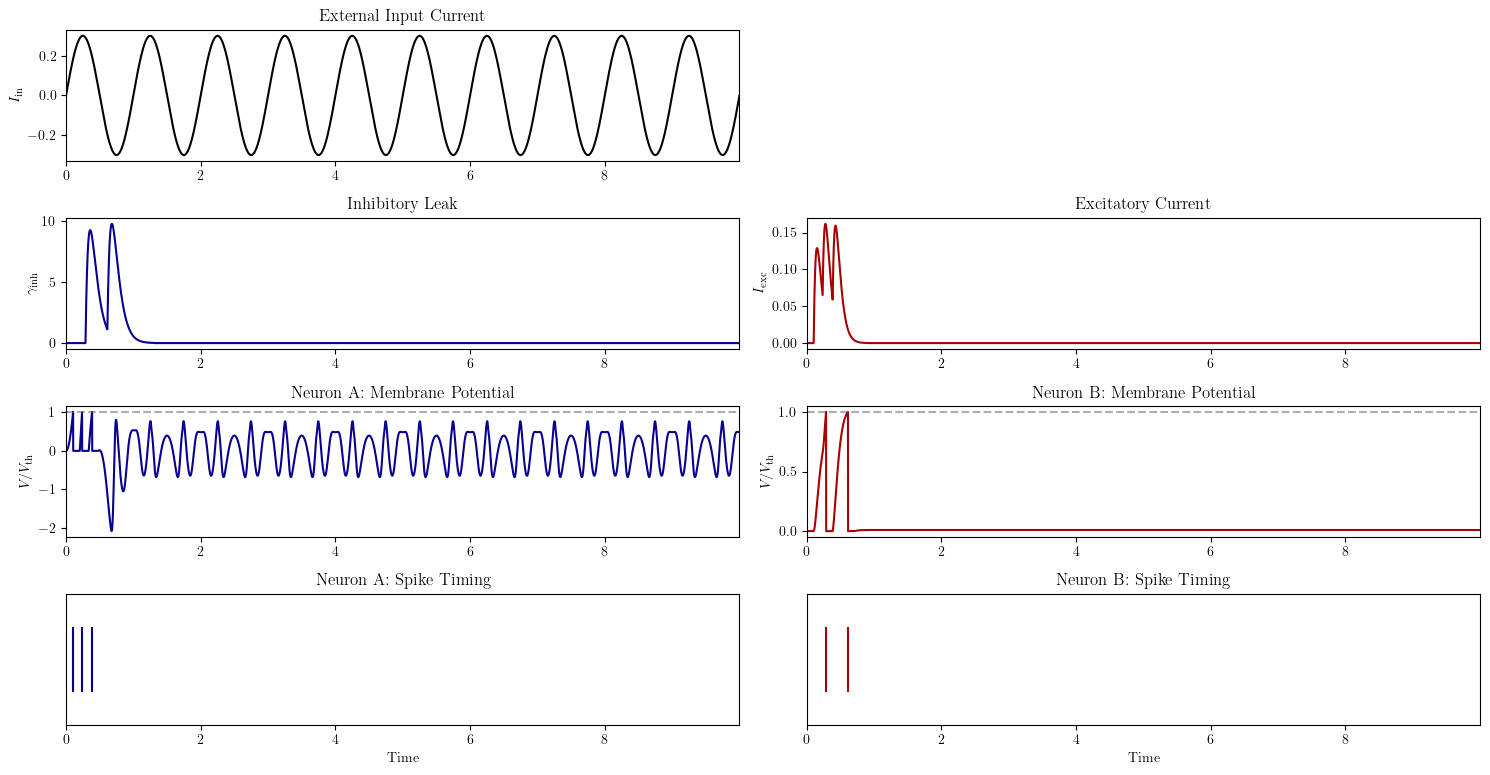

In [6]:
T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.05, tau_syn=0.05)
syn_inh = Synapse(w=0.9, tau_syn=0.07)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

simulation_data = network.simulate(T, current)
patterns_data["Transient Spiking"] = simulation_data

metrics = calculate_metrics_firing_patterns(simulation_data["spkA"])

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "transient.pdf", bbox_inches="tight")

metrics

# Irregular spiking

{'n_spikes': 33,
 't_first': 0.165,
 't_last': 14.907,
 'mean_isi': 0.46068749999999997,
 'cv_isi': 0.8689607234642943,
 'a': 0.03913979792602539}

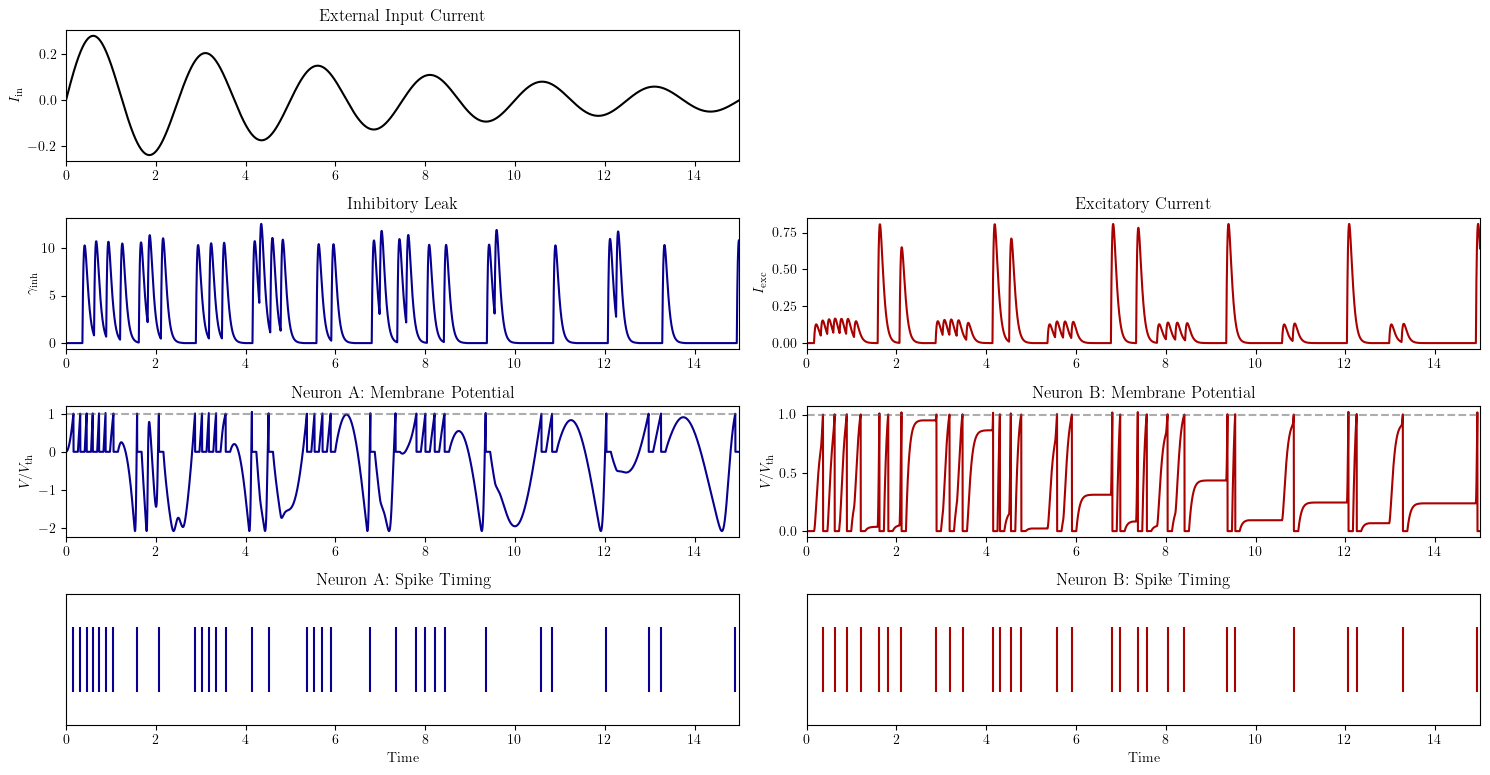

In [7]:
T =15

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

syn_exc = Synapse(w=0.05, tau_syn=0.05)
syn_inh = Synapse(w=1, tau_syn=0.05)

network = A_exc_B_inh_A(neuronA, neuronB, syn_exc, syn_inh)

current = damped_sinusoidal_current(T=T, T_in=T, I0=0.3, f=0.4, tau=8)

simulation_data = network.simulate(T, current)
patterns_data["Irregular Spiking"] = simulation_data

metrics = calculate_metrics_firing_patterns(simulation_data["spkA"])

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "irregular.pdf", bbox_inches="tight")

metrics

/Users/marta/Documents/education/um/bachelor thesis/qmlif_loop/src/analysis/plot.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


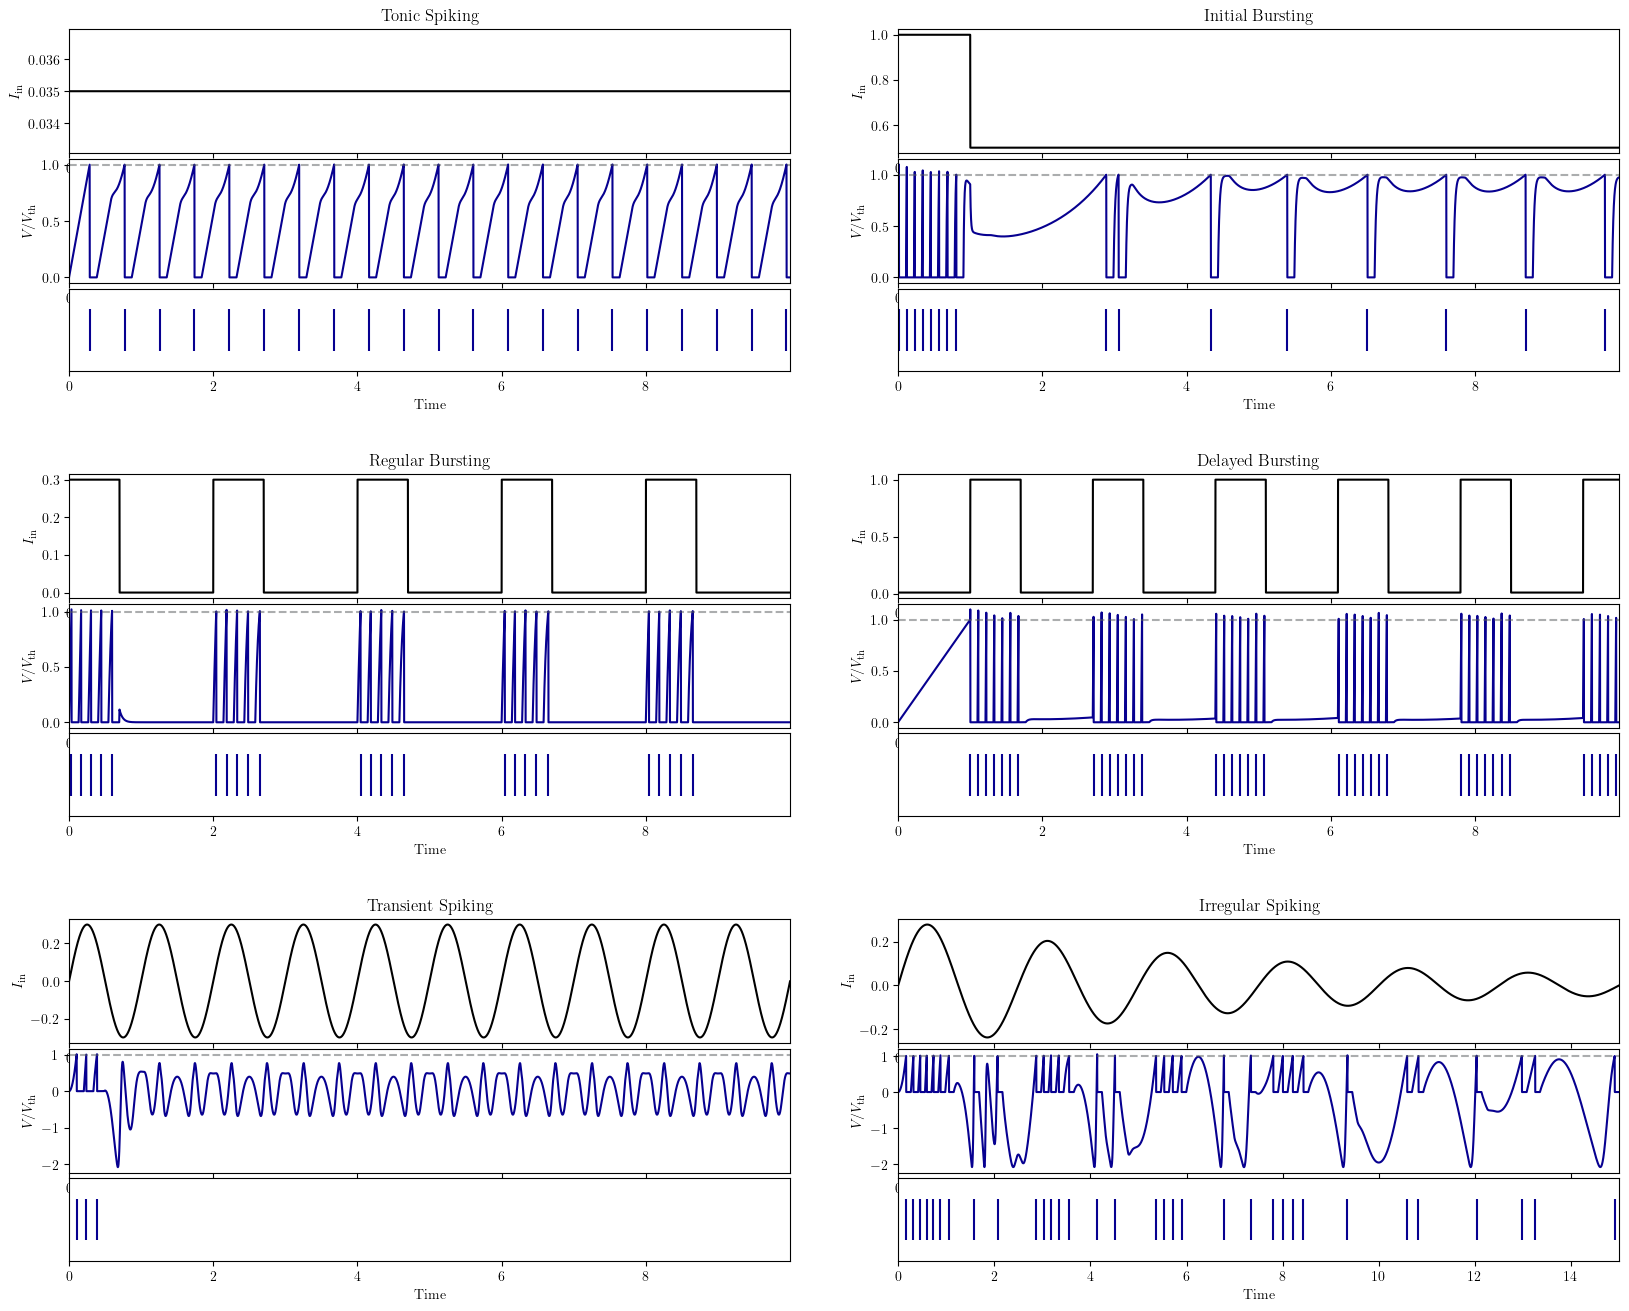

In [8]:
fig = plot.firing_patterns_panel(patterns_data)
fig.savefig(FIG_DIR / "firing_patterns_panel.pdf", bbox_inches="tight")